# Logistic Regression — SBA Loan Default Prediction

Logistic Regression is a linear classification algorithm that models the probability of a binary outcome using the logistic (sigmoid) function. It estimates the log-odds of the target as a linear combination of the input features, making it interpretable and computationally efficient.

For this SBA loan default prediction task, Logistic Regression serves as a strong, interpretable baseline. Its coefficients directly indicate how each feature influences the likelihood of default.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve, precision_recall_curve)
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

# ── Load preprocessed data ───────────────────────────────────────────────────
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Default rate — Train: {y_train.mean():.2%}, Test: {y_test.mean():.2%}")

Train: (715993, 12), Test: (178999, 12)
Default rate — Train: 17.57%, Test: 17.57%


## 1. Model Training

Logistic Regression fits a linear decision boundary in feature space. The `class_weight="balanced"` parameter automatically adjusts the loss function to penalise misclassification of the minority class (defaults) more heavily — crucial for this imbalanced dataset where only ~17% of loans defaulted. `max_iter=1000` ensures the solver has enough iterations to converge on this dataset.

In [2]:
%%time
# ── Train Logistic Regression ─────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression

# class_weight="balanced" compensates for the ~17% default rate imbalance
model = LogisticRegression(
    max_iter=1000,           # enough iterations for convergence
    class_weight="balanced", # up-weights the minority (default) class
    random_state=42
)

model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.
CPU times: user 7.42 s, sys: 860 ms, total: 8.28 s
Wall time: 13.2 s


## 2. Predictions

Using the trained model to generate both hard class labels (`y_pred`) and probability scores (`y_prob`). The probability scores are needed for ROC-AUC and Precision-Recall curve computation.

In [3]:
# ── Generate predictions ──────────────────────────────────────────────────────
y_pred = model.predict(X_test)              # hard class labels (0 or 1)
y_prob = model.predict_proba(X_test)[:, 1]  # probability of default (class 1)

print(f"Predicted defaults: {y_pred.sum()} / {len(y_pred)} ({y_pred.mean():.2%})")
print(f"Actual defaults:    {y_test.sum()} / {len(y_test)} ({y_test.mean():.2%})")

Predicted defaults: 69409 / 178999 (38.78%)
Actual defaults:    31447 / 178999 (17.57%)


## 3. Metric Analysis

### Which metric matters most for this problem?

This is an **imbalanced classification problem** (~17% default rate), which makes metric choice critical:

| Metric | Why it matters here |
|--------|-------------------|
| **Recall** | Most important. Measures how many actual defaults we caught. Missing a default (false negative) means approving a loan that will not be repaid — a direct financial loss. |
| **ROC-AUC** | Measures the model's overall discrimination ability across all thresholds. Robust to class imbalance and useful for comparing models. |
| **PR-AUC** | Even more informative than ROC-AUC on imbalanced data — focuses specifically on the minority (default) class performance. |
| **F1 Score** | Harmonic mean of Precision and Recall. Useful when you need a single number that balances both, but does not capture the full picture. |
| **Accuracy** | **Misleading here.** A naive model that predicts "no default" for every loan would achieve ~83% accuracy — yet it would be completely useless for fraud/default detection. |

**Business context:** In SBA loan default prediction, a **false negative** (predicting "paid in full" when the loan actually defaults) is far more costly than a **false positive** (flagging a good loan as risky). Therefore, we prioritise **Recall** and **ROC-AUC** when evaluating model quality.

In [4]:
# ── Compute and display all metrics ──────────────────────────────────────────
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Paid in Full", "Defaulted"]))

Accuracy:  0.6813
Precision: 0.3156
Recall:    0.6965
F1 Score:  0.4344
ROC-AUC:   0.7459

Classification Report:
              precision    recall  f1-score   support

Paid in Full       0.91      0.68      0.78    147552
   Defaulted       0.32      0.70      0.43     31447

    accuracy                           0.68    178999
   macro avg       0.61      0.69      0.61    178999
weighted avg       0.81      0.68      0.72    178999



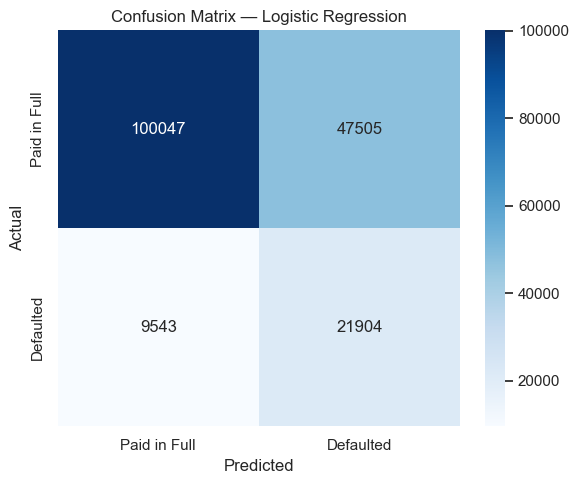

In [5]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────
# Rows = actual class, Columns = predicted class
# Top-left: true negatives (correctly predicted "Paid in Full")
# Bottom-right: true positives (correctly predicted "Defaulted")
# Bottom-left: false negatives (missed defaults — the costly errors)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Paid in Full", "Defaulted"],
            yticklabels=["Paid in Full", "Defaulted"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.show()

# The bottom-left cell (false negatives) represents defaults the model missed.
# Minimising this cell is the primary business objective.

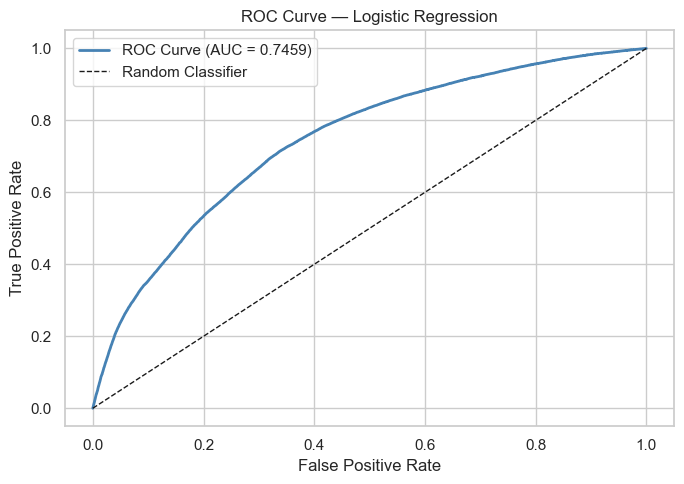

In [6]:
# ── ROC Curve ────────────────────────────────────────────────────────────────
# The ROC curve plots the True Positive Rate vs False Positive Rate at every
# classification threshold. AUC = 1.0 is perfect; AUC = 0.5 is random.
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC Curve (AUC = {auc:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Logistic Regression")
ax.legend()
plt.tight_layout()
plt.show()

# A higher AUC means the model better separates defaults from non-defaults
# across all possible decision thresholds.

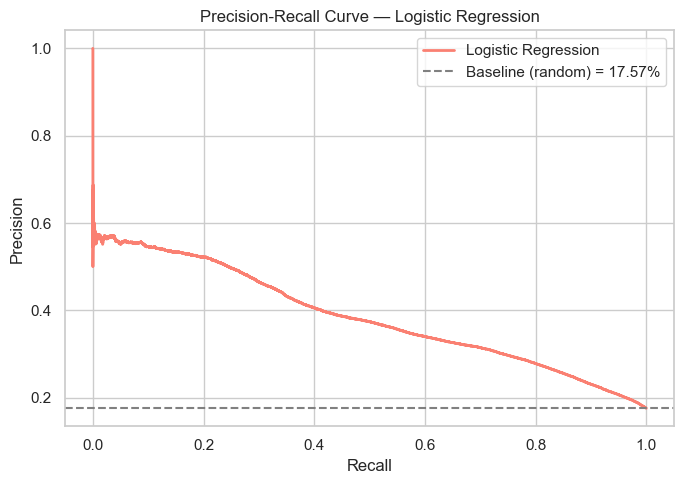

In [7]:
# ── Precision-Recall Curve ───────────────────────────────────────────────────
# The PR curve is especially informative for imbalanced datasets.
# The dashed baseline shows the precision of a random classifier (= default rate).
# A good model should stay well above this baseline.
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall_vals, precision_vals, color="salmon", lw=2, label="Logistic Regression")
ax.axhline(y=y_test.mean(), color="gray", linestyle="--",
           label=f"Baseline (random) = {y_test.mean():.2%}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — Logistic Regression")
ax.legend()
plt.tight_layout()
plt.show()

# The area under this curve (PR-AUC) rewards the model for correctly identifying
# defaults without too many false alarms. Prefer high recall (catch most defaults)
# while keeping precision reasonable.

## 4. Feature Importance (Coefficients)

Logistic Regression does not have a `feature_importances_` attribute like tree-based models. Instead, we use the model's **coefficients** as a proxy for feature importance. A large positive coefficient means the feature strongly increases the log-odds of default; a large negative coefficient means it strongly decreases it.

> Note: Because the features are preprocessed (scaled/encoded), the coefficient magnitudes are comparable across features.

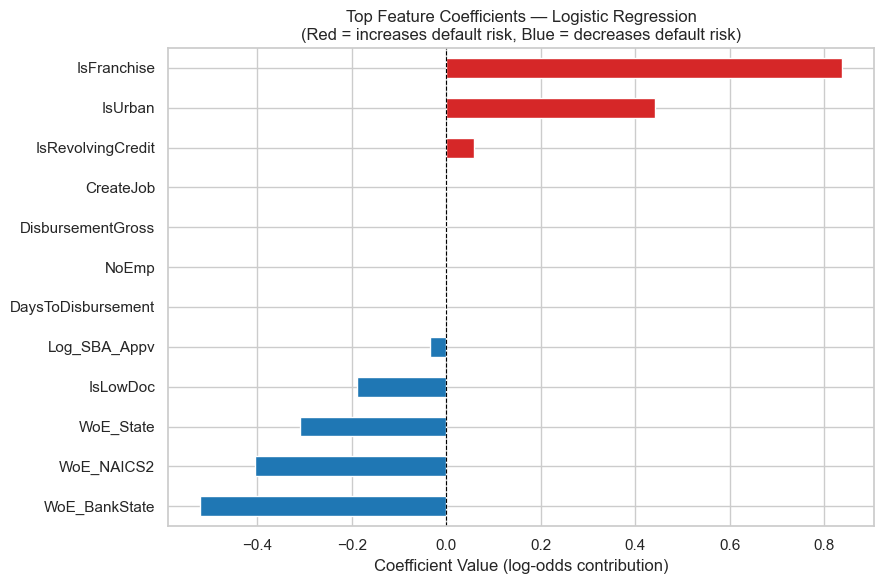

In [8]:
# ── Coefficient plot (feature importance proxy) ──────────────────────────────
# Extract coefficients and sort by value
coef_series = pd.Series(model.coef_[0], index=X_train.columns).sort_values()

# Show top 20 most impactful features (10 most negative + 10 most positive)
n = min(10, len(coef_series) // 2)
top_features = pd.concat([coef_series.head(n), coef_series.tail(n)])

# Colour bars: red = increases default risk, blue = decreases default risk
colors = ["#d62728" if c > 0 else "#1f77b4" for c in top_features]

fig, ax = plt.subplots(figsize=(9, 6))
top_features.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", lw=0.8, linestyle="--")
ax.set_xlabel("Coefficient Value (log-odds contribution)")
ax.set_title("Top Feature Coefficients — Logistic Regression\n(Red = increases default risk, Blue = decreases default risk)")
plt.tight_layout()
plt.show()

# Features with the largest absolute coefficients have the greatest influence
# on the model's prediction of loan default.